# Experiments with numerical solvers 

In [1]:
using Distributed  # for parallel computing
addprocs(4);
print(workers())

[2, 3, 4, 5]

In [2]:
@everywhere begin 
    using DifferentialEquations
    using MultiFloats
    using ProgressMeter
    
    function ode_solve(
            A::Function, 
            method::OrdinaryDiffEqAlgorithm, 
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            t0::T, 
            H::T,
            nsteps::Integer,
            retfull::Bool,
            param::Any) where T<:AbstractFloat
        
        h = H/nsteps 
        prob = SecondOrderODEProblem(A, p0, q0, (t0, t0+H), param);
        if retfull 
            sol = solve(prob, method, tstops=t0:h:(t0+H), adaptive=false, save_everystep=true);
            P = hcat([u.x[1] for u in sol.u]...)   
            Q = hcat([u.x[2] for u in sol.u]...)
            return P, Q
        else 
            sol = solve(prob, method, tstops=t0:h:(t0+H), adaptive=false, save_everystep=false);
            p = sol[end].x[1]
            q = sol[end].x[2]
            return p, q
        end
    end
    
    methods = Dict(
        "VelocityVerlet"=>VelocityVerlet(),
        "CalvoSanz4"=>CalvoSanz4(),
        "McAte5"=>McAte5(),
        "KahanLi6"=>KahanLi6(),
        "KahanLi8"=>KahanLi8(),
    )
    
    include("./setups/fpu.jl")
    
    const Dt = 1e0;
    const OMEGA = 300.;
    # const method = "McAte5";
    
    phi_Dt(p::AbstractArray{Float64, 1}, q::AbstractArray{Float64, 1}, h::Float64, method::String) = ode_solve(
        A!, methods[method], p, q, 0.0, Dt, round(Int, Dt/h), false, (Float64(OMEGA)^2)/2.)
    
    phi_Dt(p::AbstractArray{BigFloat, 1}, q::AbstractArray{BigFloat, 1}, h::Float64, method::String) = ode_solve(
        A!, methods[method], p, q, BigFloat(0.0), BigFloat(Dt), round(Int, Dt/h), false, (BigFloat(OMEGA)^2)/2.)
    
    Base.round(x::MultiFloat{Float64, 4}, y::RoundingMode) = MultiFloat{Float64, 4}(Base.round(Float64(x),y))
    Base.trunc(x::Type{Integer}, y::MultiFloat{Float64, 4}) = Base.trunc(x::Type{Integer}, Float64(y))
    
    phi_Dt(p::AbstractArray{MultiFloat{Float64, 4}, 1}, q::AbstractArray{MultiFloat{Float64, 4}, 1}, h::Float64, method::String) = ode_solve(
        A!, methods[method], p, q, Float64x4(0.0), Float64x4(Dt), round(Int, Dt/h), false, (Float64x4(OMEGA)^2)/2.)
    
    function phi_Dt_N(
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            N::Integer, 
            h::Float64,
            method::String) where T<:AbstractFloat
        
        progressbar = Progress(N)
        
        d = length(p0)
        P = zeros(T, d, N+1)
        Q = zeros(T, d, N+1)
        P[:, 1] = p0
        Q[:, 1] = q0
        
        for n in 1:N
            P[:, n+1], Q[:, n+1] = phi_Dt(P[:, n], Q[:, n], h, method)
            next!(progressbar)
        end

        return P, Q
    end 
end

In [3]:
p0, q0 = initial_condition(omega=OMEGA)

println("p0: ", p0)
println("q0: ", q0)
println("H0: ", compute_H(p0, q0, omega=OMEGA))
println("K0: ", compute_K(p0))
println("U0: ", compute_U(q0, omega=OMEGA))

p0: [0.0, 1.4142135623730951, 0.0, 0.0, 0.0, 0.0]
q0: [0.7047497585825924, 0.7094638037905027, 0.0, 0.0, 0.0, 0.0]
H0: 2.0000333333950584
K0: 1.0000000000000002
U0: 1.0000333333950582


In [4]:
p0_bf, q0_bf = initial_condition(omega=BigFloat(OMEGA))

println("p0: ", p0_bf)
println("q0: ", q0_bf)
println("H0: ", compute_H(p0_bf, q0_bf, omega=BigFloat(OMEGA)))
println("K0: ", compute_K(p0_bf))
println("U0: ", compute_U(q0_bf, omega=BigFloat(OMEGA)))

p0: BigFloat[0.0, 1.414213562373095048801688724209698078569671875376948073176679737990732478462102, 0.0, 0.0, 0.0, 0.0]
q0: BigFloat[0.7047497585825923659861748808978328758205531512295124564663787360987150184336224, 0.7094638037905026828155138433118652027491187241474356167103010018920174600284883, 0.0, 0.0, 0.0, 0.0]
H0: 2.000033333395061728395061728395061728395061728395061728395061728395061728393397
K0: 0.9999999999999999999999999999999999999999999999999999999999999999999999999999914
U0: 1.000033333395061728395061728395061728395061728395061728395061728395061728393414


In [5]:
p0_f256, q0_f256 = initial_condition(omega=Float64x4(OMEGA))

println("p0: ", p0_f256)
println("q0: ", q0_f256)
println("H0: ", compute_H(p0_f256, q0_f256, omega=Float64x4(OMEGA)))
println("K0: ", compute_K(p0_f256))
println("U0: ", compute_U(q0_f256, omega=Float64x4(OMEGA)))

p0: MultiFloat{Float64, 4}[0.0, 1.414213562373095048801688724209698078569671875376948073176679738104, 0.0, 0.0, 0.0, 0.0]
q0: MultiFloat{Float64, 4}[0.70474975858259236598617488089783287582055315122951245646637873603984, 0.70946380379050268281551384331186520274911872414743561671030100179855, 0.0, 0.0, 0.0, 0.0]
H0: 2.0000333333950617283950617283950617283950617283950617283950617209176
K0: 1.00000000000000000000000000000000000000000000000000000000000000007596454196607839
U0: 1.0000333333950617283950617283950617283950617283950617283950617208416


In [6]:
using LinearAlgebra
using Plots

function compute_traj_err(sol, ref_sol) 
    return norm(sol .- ref_sol)/norm(ref_sol)
end 

function compute_H_err(sol, ref_sol; omega=OMEGA)
    omega = convert(typeof(sol[1][1]), omega)
    return abs(compute_H(sol...; omega=omega) - compute_H(ref_sol...; omega=omega)) / abs(compute_H(ref_sol...; omega=omega))
end 

compute_H_err (generic function with 1 method)

## 1. Find fine step size that's reasonably accurate

In [7]:
h_list = 2.0 .^[-6, -8, -10, -12, -14, -16, -18]

7-element Vector{Float64}:
 0.015625
 0.00390625
 0.0009765625
 0.000244140625
 6.103515625e-5
 1.52587890625e-5
 3.814697265625e-6

In [8]:
method_list = ["VelocityVerlet", "CalvoSanz4", "McAte5", "KahanLi6", "KahanLi8"]

5-element Vector{String}:
 "VelocityVerlet"
 "CalvoSanz4"
 "McAte5"
 "KahanLi6"
 "KahanLi8"

### 1.1 Float64

In [9]:
res = [phi_Dt(p0, q0, h, m) for h in h_list, m in method_list]

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


7×5 Matrix{Tuple{Vector{Float64}, Vector{Float64}}}:
 ([-5.21246e55, 8.84293e62, -8.84293e62, 9.78478e26, -9.77942e26, 4.41974e11], [1.18594e19, -1.52365e21, 1.52365e21, -1.89412e9, 1.25717e9, -25.836])  …  ([-1.06771, -0.453788, 0.564355, 0.567417, 0.0198942, 0.0198832], [0.521741, 0.535803, 0.38814, 0.38813, 0.00280081, 0.00279826])
 ([-1.40689, -0.114691, 0.569306, 0.562498, 0.0198997, 0.0198846], [0.526096, 0.531376, 0.388132, 0.388172, 0.00280107, 0.00279851])                      ([-1.46022, -0.0613571, 0.560592, 0.571208, 0.0198973, 0.0198846], [0.53112, 0.526362, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.71654, 0.194953, 0.565889, 0.56591, 0.0198985, 0.0198836], [0.52781, 0.529672, 0.38813, 0.388168, 0.00280114, 0.0027986])                           ([-1.45917, -0.0624068, 0.560588, 0.571212, 0.0198973, 0.0198846], [0.531124, 0.526359, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.50511, -0.016464, 0.560787, 0.571013, 0.0198974, 0.0198845], [0.530964, 0.526519, 0.

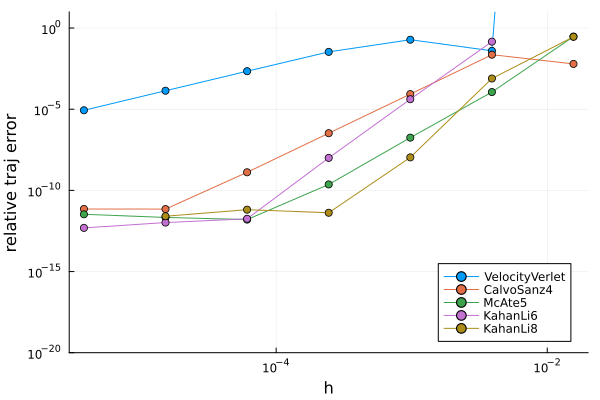

In [31]:
errors = [compute_traj_err(res[i, j], res[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-20, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")
plot!(legend=:bottomright)

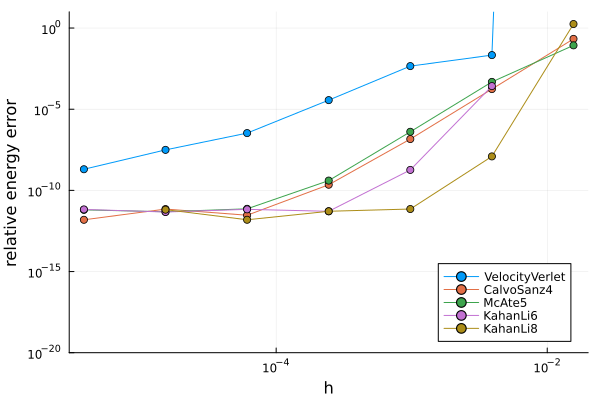

In [17]:
errors = [compute_H_err(res[i, j], res[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-20, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")
plot!(legend=:bottomright)

In [19]:
sol = phi_Dt(p0, q0, 2^(-12), "McAte5")
ref_sol = phi_Dt(p0, q0, 2^(-14), "KahanLi8")
println("relative traj relerr = ", compute_traj_err(sol, ref_sol))
println("relative energy relerr = ", compute_H_err(sol, ref_sol))

relative traj relerr = 2.391972243162846e-10
relative energy relerr = 3.9992475589043603e-10


### 1.2 BigFloat

In [30]:
res_bf = [phi_Dt(p0_bf, q0_bf, h, m) for h in h_list, m in method_list]

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


7×5 Matrix{Tuple{Vector{BigFloat}, Vector{BigFloat}}}:
 ([NaN, NaN, NaN, Inf, -Inf, 3.97465e+1298747418474521919], [Inf, -Inf, Inf, -3.76746e+1222354549880186113, 3.76746e+1222354549880186113, -5.02902e+432915806158173973])  …  ([-1.06771, -0.453788, 0.564355, 0.567417, 0.0198942, 0.0198832], [0.521741, 0.535803, 0.38814, 0.38813, 0.00280081, 0.00279826])
 ([-1.40689, -0.114691, 0.569306, 0.562498, 0.0198997, 0.0198846], [0.526096, 0.531376, 0.388132, 0.388172, 0.00280107, 0.00279851])                                         ([-1.46022, -0.0613571, 0.560592, 0.571208, 0.0198973, 0.0198846], [0.53112, 0.526362, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.71654, 0.194953, 0.565889, 0.56591, 0.0198985, 0.0198836], [0.52781, 0.529672, 0.38813, 0.388168, 0.00280114, 0.0027986])                                              ([-1.45917, -0.0624068, 0.560588, 0.571212, 0.0198973, 0.0198846], [0.531124, 0.526359, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.50511, -0.016464, 0.56078

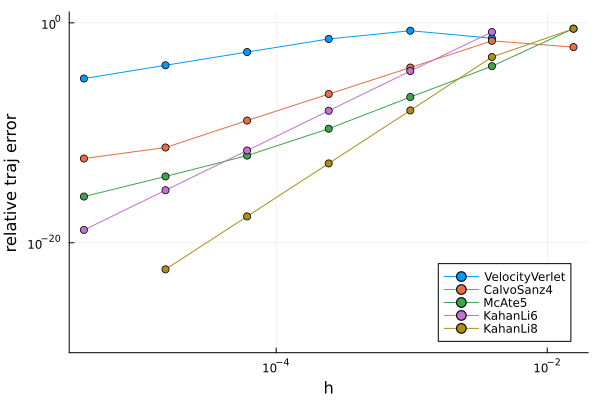

In [32]:
errors = [compute_traj_err(res_bf[i, j], res_bf[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")
plot!(legend=:bottomright)

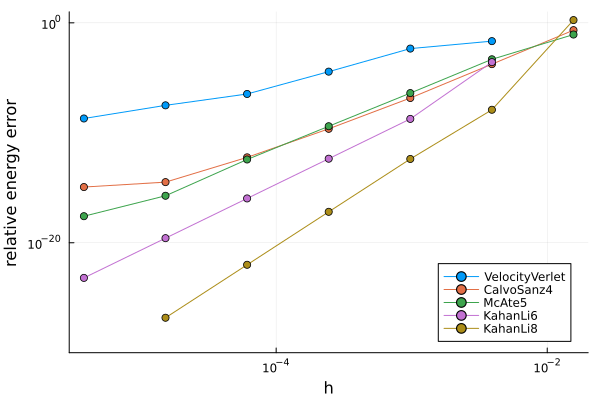

In [33]:
errors = [compute_H_err(res_bf[i, j], res_bf[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")
plot!(legend=:bottomright)

### 1.3 Float64x4

In [20]:
res_f256 = [phi_Dt(p0_f256, q0_f256, h, m) for h in h_list, m in method_list]

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


7×5 Matrix{Tuple{Vector{MultiFloat{Float64, 4}}, Vector{MultiFloat{Float64, 4}}}}:
 ([NaN, NaN, NaN, 2.77874e+222, -2.77874e+222, 7.69154e+80], [4.22063e+159, -1.64865e+182, 1.64865e+182, -2.2317e+74, 2.2317e+74, -2.90875e+27])  …  ([-1.06771, -0.453788, 0.564355, 0.567417, 0.0198942, 0.0198832], [0.521741, 0.535803, 0.38814, 0.38813, 0.00280081, 0.00279826])
 ([-1.40689, -0.114691, 0.569306, 0.562498, 0.0198997, 0.0198846], [0.526096, 0.531376, 0.388132, 0.388172, 0.00280107, 0.00279851])                 ([-1.46022, -0.0613571, 0.560592, 0.571208, 0.0198973, 0.0198846], [0.53112, 0.526362, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.71654, 0.194953, 0.565889, 0.56591, 0.0198985, 0.0198836], [0.52781, 0.529672, 0.38813, 0.388168, 0.00280114, 0.0027986])                      ([-1.45917, -0.0624068, 0.560588, 0.571212, 0.0198973, 0.0198846], [0.531124, 0.526359, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.50511, -0.016464, 0.560787, 0.571013, 0.0198974, 0.0198845], [0.53096

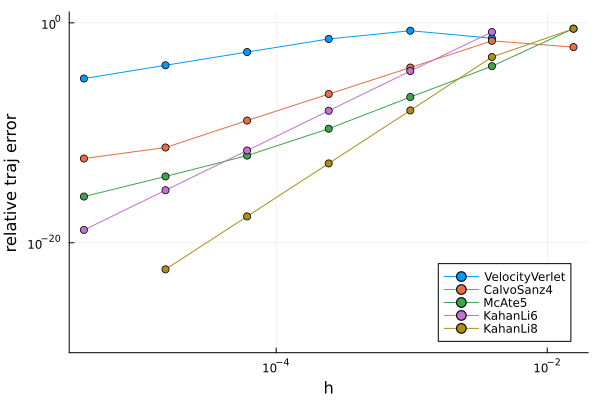

In [29]:
errors = [compute_traj_err(res_f256[i, j], res_f256[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")
plot!(legend=:bottomright)

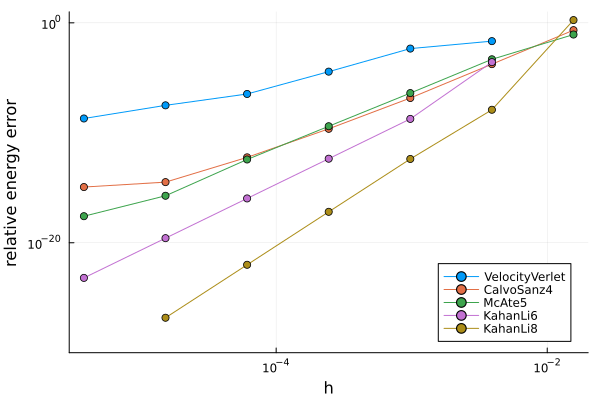

In [24]:
errors = [compute_H_err(res_f256[i, j], res_f256[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")
plot!(legend=:bottomright)

## 2. Measure runtime

In [34]:
using BenchmarkTools

In [35]:
h_list = 2.0 .^[-6, -8, -10, -12, -14, -16, -18]

7-element Vector{Float64}:
 0.015625
 0.00390625
 0.0009765625
 0.000244140625
 6.103515625e-5
 1.52587890625e-5
 3.814697265625e-6

In [36]:
method_list = ["VelocityVerlet", "CalvoSanz4", "McAte5", "KahanLi6", "KahanLi8"]

5-element Vector{String}:
 "VelocityVerlet"
 "CalvoSanz4"
 "McAte5"
 "KahanLi6"
 "KahanLi8"

### 2.1 Float64

In [37]:
@benchmark phi_Dt(p0, q0, 2^(-16), "McAte5")

BenchmarkTools.Trial: 249 samples with 1 evaluation.
 Range (min … max):  19.787 ms …  27.011 ms  ┊ GC (min … max): 0.00% … 24.29%
 Time  (median):     20.006 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   20.087 ms ± 612.319 μs  ┊ GC (mean ± σ):  0.25% ±  2.11%

    ▃  ▁▅▆▁▅█▁▃▁▅▃▅▂▁▁   ▂▁                                     
  ▄▆██▅████████████████▄▆██▄▆▅▃▇▅▄▅▄▁▄▃▅▃▃▅▃▁▃▁▃▁▁▁▁▃▃▁▃▁▁▁▁▁▃ ▄
  19.8 ms         Histogram: frequency by time         20.7 ms <

 Memory estimate: 1.86 MiB, allocs estimate: 650.

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


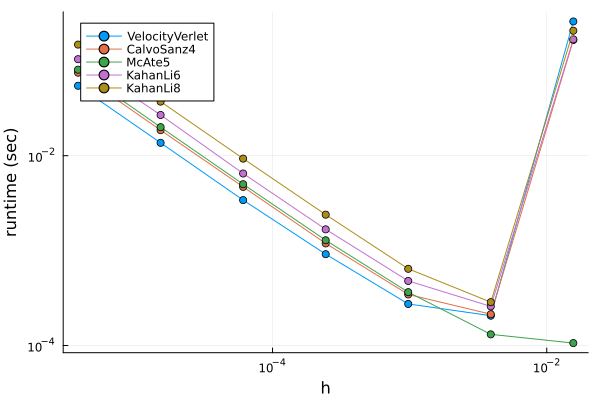

In [38]:
runtimes = [@elapsed phi_Dt(p0, q0, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")

### 2.2 BigFloat

In [39]:
@benchmark phi_Dt(p0_bf, q0_bf, 2^(-16), "McAte5")

BenchmarkTools.Trial: 2 samples with 1 evaluation.
 Range (min … max):  2.537 s …   2.585 s  ┊ GC (min … max): 9.25% … 9.26%
 Time  (median):     2.561 s              ┊ GC (median):    9.25%
 Time  (mean ± σ):   2.561 s ± 34.559 ms  ┊ GC (mean ± σ):  9.25% ± 0.01%

  █                                                       █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  2.54 s         Histogram: frequency by time        2.59 s <

 Memory estimate: 3.54 GiB, allocs estimate: 73008318.

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


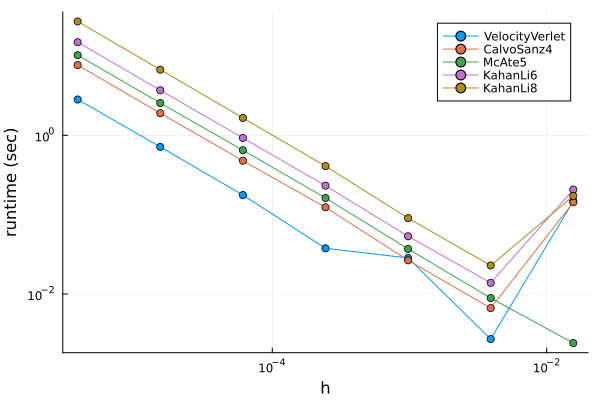

In [40]:
runtimes = [@elapsed phi_Dt(p0_bf, q0_bf, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")

### 2.3 Float64x4

In [41]:
@benchmark phi_Dt(p0_f256, q0_f256, 2^(-16), "McAte5")

BenchmarkTools.Trial: 10 samples with 1 evaluation.
 Range (min … max):  511.460 ms … 525.438 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     513.482 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   515.244 ms ±   4.541 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ███  █  ██  █            █             █                    █  
  ███▁▁█▁▁██▁▁█▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  511 ms           Histogram: frequency by time          525 ms <

 Memory estimate: 5.46 MiB, allocs estimate: 939.

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


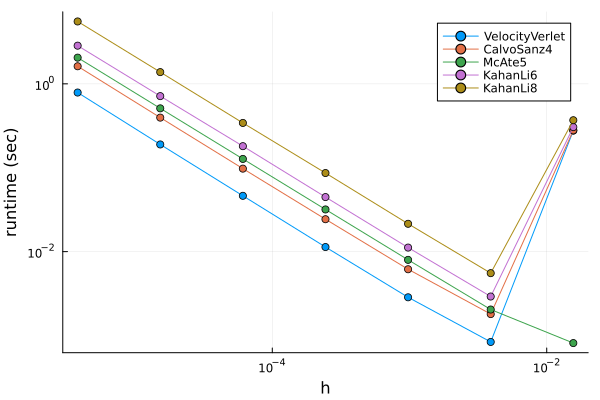

In [42]:
runtimes = [@elapsed phi_Dt(p0_f256, q0_f256, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")

## 3. Measure stability 

In [7]:
include("./generate_data_utils.jl")
using Printf

In [21]:
p0_ptb = p0 .+ 1e-14;
q0_ptb = q0 .+ 1e-14;

p0_ptb_bf = p0_bf .+ 1e-14;
q0_ptb_bf = q0_bf .+ 1e-14;

p0_ptb_f256 = p0_f256 .+ 1e-14;
q0_ptb_f256 = q0_f256 .+ 1e-14;

In [22]:
N = 200
method = "McAte5"
rootdir = "./stability/omega=300/ma5"

for h in 2.0 .^[-8, -10, -12, -14, -16, -18]
    # Float64
    P, Q = phi_Dt_N(p0, q0, N, h, method)
    save_csv("$rootdir/f64/h=$(@sprintf("%.4e", h))/sol.csv", P, Q, Float64)
    
    P_ptb, Q_ptb = phi_Dt_N(p0_ptb, q0_ptb, N, h, method)
    save_csv("$rootdir/f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb, Q_ptb, Float64)
    
#     # BigFloat
#     P_bf, Q_bf = phi_Dt_N(p0_bf, q0_bf, N, h, method)
#     save_csv("$rootdir/bf/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, BigFloat)
#     save_csv("$rootdir/bf_f64/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, Float64)
    
#     P_ptb_bf, Q_ptb_bf = phi_Dt_N(p0_ptb_bf, q0_ptb_bf, N, h, method)
#     save_csv("$rootdir/bf/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, BigFloat)
#     save_csv("$rootdir/bf_f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, Float64)
    
    # Float64x4
    P_f256, Q_f256 = phi_Dt_N(p0_f256, q0_f256, N, h, method)
    save_csv("$rootdir/f64x4/h=$(@sprintf("%.4e", h))/sol.csv", P_f256, Q_f256, Float64x4)
    save_csv("$rootdir/f64x4_f64/h=$(@sprintf("%.4e", h))/sol.csv", P_f256, Q_f256, Float64)
    
    P_ptb_f256, Q_ptb_f256 = phi_Dt_N(p0_ptb_f256, q0_ptb_f256, N, h, method)
    save_csv("$rootdir/f64x4/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_f256, Q_ptb_f256, Float64x4)
    save_csv("$rootdir/f64x4_f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_f256, Q_ptb_f256, Float64)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:06
Progress: 100%|█████████████████████████████████████████| Time: 0:00:06
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
Progress: 100%|█████████████████████████████████████████| Time: 

In [18]:
P, Q = read_csv("./stability/omega=300/kl8/f64x4/h=$(@sprintf("%.4e", 2^(-8)))/sol.csv", Float64x4);
# P_bf, Q_bf = read_csv("./stability/omega=300/kl6/bigfloat/h=3.814697265625e-6/sol.csv", BigFloat);

In [4]:
P_diff = P_bf[:, 1:201] - P_bf_ref[:, 1:201];
P_diff

6×201 Matrix{BigFloat}:
 0.0  -1.96921e-19  -3.76276e-19   6.10307e-19  …   1.21925e-14  -1.90589e-14
 0.0   1.96914e-19   3.76314e-19  -6.10307e-19      1.19993e-14  -1.93679e-14
 0.0   7.49696e-22  -4.26657e-21  -6.01684e-21     -4.16015e-16   3.59131e-16
 0.0  -7.50178e-22   4.22687e-21   6.01753e-21     -6.54688e-16   3.03321e-16
 0.0   5.20032e-25   5.92812e-24  -2.60418e-23     -1.08242e-14   1.80099e-14
 0.0  -4.9199e-25   -6.02944e-24   2.55594e-23  …  -1.09345e-14   1.82166e-14

In [5]:
Q_diff = Q_bf[:, 1:201]  - Q_bf_ref[:, 1:201];
Q_diff

6×201 Matrix{BigFloat}:
 0.0  -6.40643e-22   1.33317e-21   1.84671e-21  …   6.28157e-15   6.09134e-15
 0.0   6.40447e-22  -1.33346e-21  -1.8465e-21       6.28112e-15   6.09184e-15
 0.0  -4.88841e-24  -8.84334e-24   2.90885e-23     -3.53164e-16  -2.53298e-15
 0.0   4.96504e-24   8.88253e-24  -2.9556e-23      -3.53203e-16  -2.53216e-15
 0.0   1.72679e-27  -5.27963e-27  -4.10693e-26     -8.71154e-15  -6.49122e-15
 0.0   1.2542e-28    7.06809e-26   5.49663e-26  …  -8.7112e-15   -6.49085e-15

In [182]:
P_bf_f64 - convert.(Float64, P_f128)

6×101 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [156]:
convert.(BigFloat, convert.(Float64, P_f128))[:, 2]

6-element Vector{BigFloat}:
 -1.4591698294104471500531872152350842952728271484375
 -0.0624068593408681759893141816064598970115184783935546875
  0.5605875226019476631478255512774921953678131103515625
  0.57121235003515191674949846856179647147655487060546875
  0.0198972778182629379817303316713150707073509693145751953125
  0.0198846465757328803858339227872420451603829860687255859375

In [157]:
convert.(Float64, P_f128)[:, 2]

6-element Vector{Float64}:
 -1.4591698294104472
 -0.062406859340868176
  0.5605875226019477
  0.5712123500351519
  0.019897277818262938
  0.01988464657573288

In [176]:
Q_bf - Q_f128

6×101 Matrix{BigFloat}:
 0.0   0.0          0.0  -1.07952e-78  …   0.0          0.0   0.0
 0.0   0.0          0.0   0.0              0.0          0.0  -2.15904e-78
 0.0  -4.31808e-78  0.0   0.0              0.0          0.0   0.0
 0.0   0.0          0.0   0.0              0.0          0.0   0.0
 0.0   0.0          0.0   0.0             -5.39761e-79  0.0   4.31808e-78
 0.0   0.0          0.0   0.0          …   0.0          0.0   0.0

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


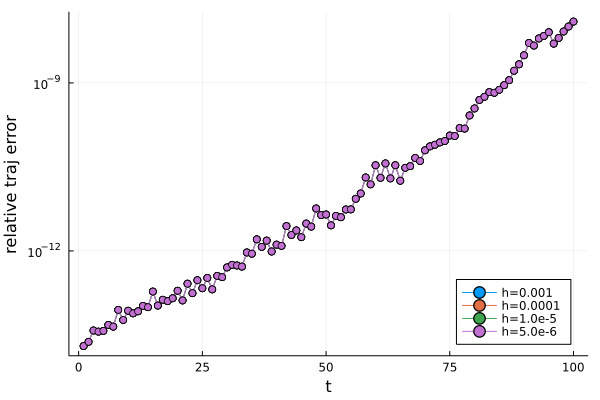

In [99]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in stability_res_f128
    errors_h = []
    for n in 1:100
        err = compute_traj_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:N), errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


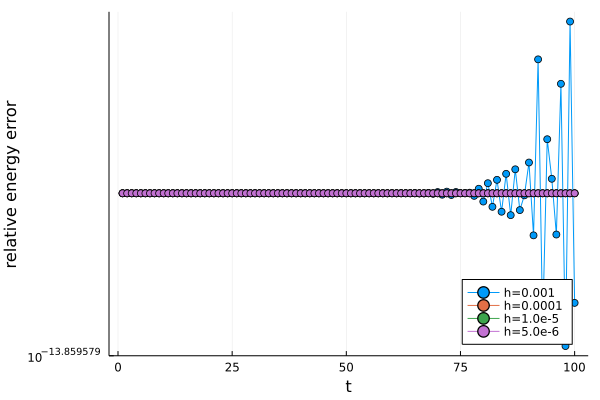

┌ Warning: No strict ticks found
└ @ PlotUtils /workspace/project_Rui/.julia/packages/PlotUtils/VgXdq/src/ticks.jl:294
┌ Warning: No strict ticks found
└ @ PlotUtils /workspace/project_Rui/.julia/packages/PlotUtils/VgXdq/src/ticks.jl:294


In [101]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in stability_res_f128
    errors_h = []
    for n in 1:100
        err = compute_H_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:100), errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative energy error")
plot!(legend=:bottomright)

## Find CalvoSanz and Velocity Verlet step sizes that generate similar level of accuracy as NN

In [19]:
@everywhere begin 
    
    phi_Dt_CS(p, q, h_CS) = ode_solve(A, CalvoSanz4(), p, q, 0.0, Dt, round(Int, Dt/h_CS), false)
    phi_Dt_VV(p, q, h_VV) = ode_solve(A, VelocityVerlet(), p, q, 0.0, Dt, round(Int, Dt/h_VV), false)
    
end

In [1]:
using CSV 
using DataFrames

In [2]:
df_init = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/X.csv"));
df_final = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/Y.csv"));

In [14]:
div(size(df_init)[2], 2)

6

In [15]:
df_init[:, 1:3]

,p1,p2,p3
,Float64,Float64,Float64
1,1.20737,-0.279278,-0.745425
2,0.214214,-1.1025,0.434747
3,-0.357103,0.800476,-0.340655
4,-1.49277,-0.210345,0.0403567
5,0.0136592,1.45386,0.601766
6,0.357872,0.519819,-0.17021
7,0.0412103,1.39902,-0.474584
8,-0.680954,0.810106,0.168413
9,0.460773,0.0431027,-0.000468713


In [12]:
l = 1
nsamples = 40080
P_init = Matrix(df_init[1:l:nsamples, 1:6])'; 
Q_init = Matrix(df_init[1:l:nsamples, 7:12])';
P_final = Matrix(df_final[1:l:nsamples, 1:6])'; 
Q_final = Matrix(df_final[1:l:nsamples, 7:12])';

In [21]:
function accuracy_VV(timestep)
    res = pmap((p, q)->phi_Dt_VV(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_VV = hcat([p for (p, q) in res]...);
    Q_VV = hcat([q for (p, q) in res]...);

    SE = sum((P_VV - P_final) .^2, dims=1) + sum((Q_VV - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_VV (generic function with 1 method)

In [23]:
function accuracy_CS(timestep)
    res = pmap((p, q)->phi_Dt_CS(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_CS = hcat([p for (p, q) in res]...);
    Q_CS = hcat([q for (p, q) in res]...);

    SE = sum((P_CS - P_final) .^2, dims=1) + sum((Q_CS - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_CS (generic function with 1 method)

In [22]:
for nsteps_VV in [32, 64, 128]
    h_VV = Dt/nsteps_VV
    println(h_VV, " ", nsteps_VV, " ", accuracy_VV(h_VV))
end

0.03125 32 0.6278326283974353
0.015625 64 1.4437819082575212
0.0078125 128 0.10294198825932901


In [24]:
for nsteps_CS in [8, 16, 32]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.125 8 12.113986319436153
0.0625 16 20.929485064488254
0.03125 32 0.0005649300775061397


In [25]:
for nsteps_CS in [64, 128]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.015625 64 2.034209929224812e-6
0.0078125 128 7.768522155694077e-9


In [30]:
@time for i in 1:1000 phi_Dt_VV(v0, x0, 1.5625e-5) end 

  1.069980 seconds (14.36 M allocations: 1.330 GiB, 22.04% gc time)


In [33]:
@time for i in 1:64 phi_Dt_CS(p0, q0, Dt/64) end 

  0.832354 seconds (11.10 M allocations: 1022.842 MiB, 21.92% gc time)


In [16]:
using Plots

In [107]:
histogram(vec(SE))

LoadError: InexactError: trunc(Int64, 2.3271148548353484e40)

In [139]:
H_init = pmap(compute_hamiltonian, eachslice(V_init, dims=2), eachslice(X_init, dims=2));
H_final = pmap(compute_hamiltonian, eachslice(V_final, dims=2), eachslice(X_final, dims=2));

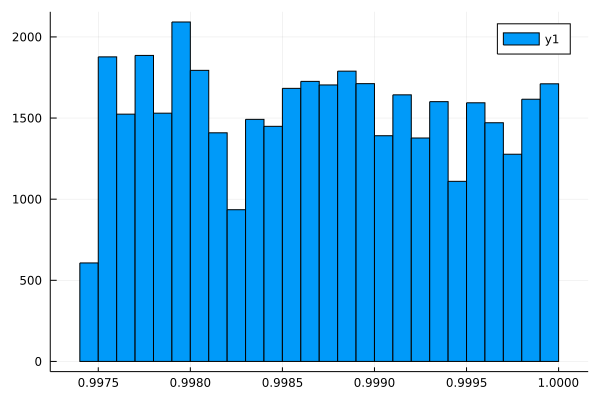

In [140]:
histogram(vec(H_init/H0))

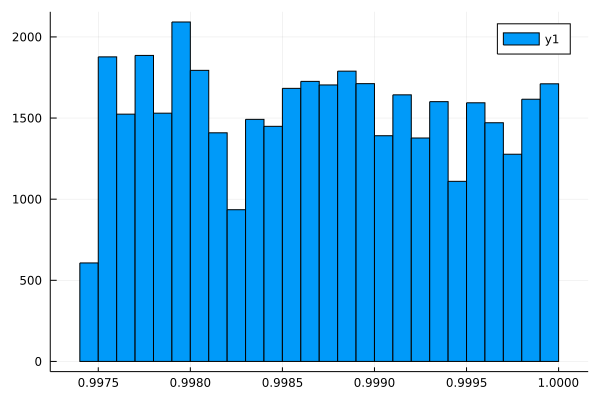

In [141]:
histogram(vec(H_final/H0))